In [2]:
import ast
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

from xgboost import XGBRegressor
import sys
from pathlib import Path

repo_root = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "src" / "training" / "data_utils.py").is_file()
)
sys.path.insert(0, str(repo_root / "src"))
from training.data_utils import canonical_legacy_track_id_split


In [3]:
artist_df = pd.read_csv("../../../../data/SpotGenTrack/Data Sources/spotify_artists.csv", index_col=0)
songs_df = pd.read_csv("../../../../data/SpotGenTrack/Data Sources/spotify_tracks.csv", index_col=0)

artist_df["genres"] = artist_df["genres"].apply(ast.literal_eval)

In [4]:
genre_counts = Counter()

for genres in artist_df["genres"]:
    genre_counts.update(genres)

print("Unique genres:", len(genre_counts))
print(genre_counts.most_common(20))

Unique genres: 2453
[('pop', 543), ('dance pop', 485), ('rock', 431), ('folk-pop', 402), ('pop rap', 387), ('modern rock', 386), ('edm', 375), ('electro house', 362), ('latin rock', 335), ('indie rock', 334), ('tropical house', 329), ('hip hop', 326), ('rap', 323), ('latin', 314), ('indie folk', 306), ('classical performance', 304), ('alternative r&b', 295), ('focus', 291), ('chamber pop', 282), ('indie r&b', 280)]


In [5]:
top_genres = [g for g, _ in genre_counts.most_common(100)]

for genre in top_genres:
    artist_df[f"genre_{genre}"] = artist_df["genres"].apply(
        lambda x: int(genre in x)
    )

/var/folders/3w/n68_h2cn529_09kydqndpd3w0000gn/T/ipykernel_12475/3680163728.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  artist_df[f"genre_{genre}"] = artist_df["genres"].apply(


In [6]:
artist_features = (
    artist_df.groupby("track_id")
    .agg(
        artist_popularity=("artist_popularity", "mean"),
        followers=("followers", "mean"),
        num_artists=("id", "count"),
        **{
            f"genre_{genre}": (f"genre_{genre}", "max")
            for genre in top_genres
        }
    )
    .reset_index()
)

/var/folders/3w/n68_h2cn529_09kydqndpd3w0000gn/T/ipykernel_12475/790970893.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index()


In [7]:
df = pd.merge(
    songs_df,
    artist_features,
    left_on="id",
    right_on="track_id",
    how="inner"
)

In [8]:
drop_cols = [
    "track_id",        # track ID from artist features
    "name",            # song name
    "track_name_prev", # duplicate song name
    "artists_id",      # artist ID
    "album_id",
    "analysis_url",
    "href",
    "preview_url",
    "track_href",
    "uri",
    "lyrics",
    "available_markets",
    "country",
    "type",
    "track_number",
    "disc_number",
    "playlist"
]

df = df.drop(columns=drop_cols, errors="ignore")

In [9]:
print(df.select_dtypes(exclude=[np.number]).columns)

Index(['id'], dtype='str')


In [10]:
target = "popularity"

track_ids = df["id"].astype(str)
X = df.drop(columns=[target, "id"])
y = df[target]

train_ids, validation_ids, test_ids = map(
    set, canonical_legacy_track_id_split()
)
train_mask = track_ids.isin(train_ids)
validation_mask = track_ids.isin(validation_ids)
test_mask = track_ids.isin(test_ids)

X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_val, y_val = X.loc[validation_mask], y.loc[validation_mask]
X_test, y_test = X.loc[test_mask], y.loc[test_mask]

print(X.shape)
print(y.shape)


legacy deterministic random split train=71359, validation=15290, test=15290
(44892, 116)
(44892,)


In [11]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [12]:
# Predictions
y_train_pred = xgb.predict(X_train)
y_val_pred = xgb.predict(X_val)
y_test_pred = xgb.predict(X_test)

# R²
train_r2 = r2_score(y_train, y_train_pred)
val_r2 = r2_score(y_val, y_val_pred)
test_r2 = r2_score(y_test, y_test_pred)

# RMSE
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

# MAE
train_mae = mean_absolute_error(y_train, y_train_pred)
val_mae = mean_absolute_error(y_val, y_val_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print(f"Train R2: {train_r2:.4f}")
print(f"Validation R2: {val_r2:.4f}")
print(f"Test R2: {test_r2:.4f}")

print(f"Train RMSE: {train_rmse:.4f}")
print(f"Validation RMSE: {val_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")

print(f"Train MAE: {train_mae:.4f}")
print(f"Validation MAE: {val_mae:.4f}")
print(f"Test MAE: {test_mae:.4f}")

Train R2: 0.7617
Validation R2: 0.6657
Test R2: 0.6880
Train RMSE: 7.5693
Validation RMSE: 8.8685
Test RMSE: 8.5600
Train MAE: 5.7601
Validation MAE: 6.6343
Test MAE: 6.4862


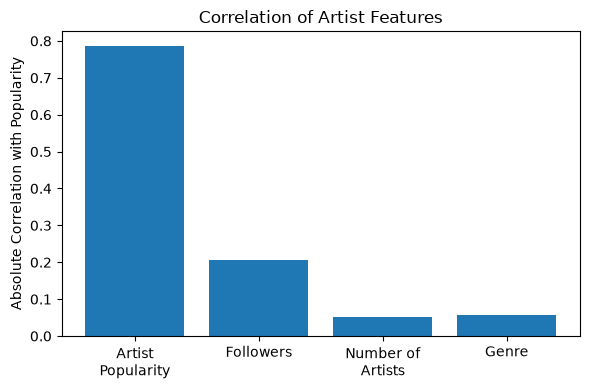

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

train_df = X_train.copy()
train_df[target] = y_train

# Find all genre columns
genre_cols = [col for col in train_df.columns if col.startswith("genre_")]

# Average absolute correlation across all genres
genre_corr = (
    train_df[genre_cols]
    .corrwith(train_df[target])
    .abs()
    .mean()
)

# Correlations for the other three features
artist_pop_corr = abs(train_df["artist_popularity"].corr(train_df[target]))
followers_corr = abs(train_df["followers"].corr(train_df[target]))
num_artists_corr = abs(train_df["num_artists"].corr(train_df[target]))

# Plot
correlations = {
    "Artist\nPopularity": artist_pop_corr,
    "Followers": followers_corr,
    "Number of\nArtists": num_artists_corr,
    "Genre": genre_corr,
}

plt.figure(figsize=(6,4))
plt.bar(correlations.keys(), correlations.values())
plt.ylabel("Absolute Correlation with Popularity")
plt.title("Correlation of Artist Features")
plt.tight_layout()
plt.show()

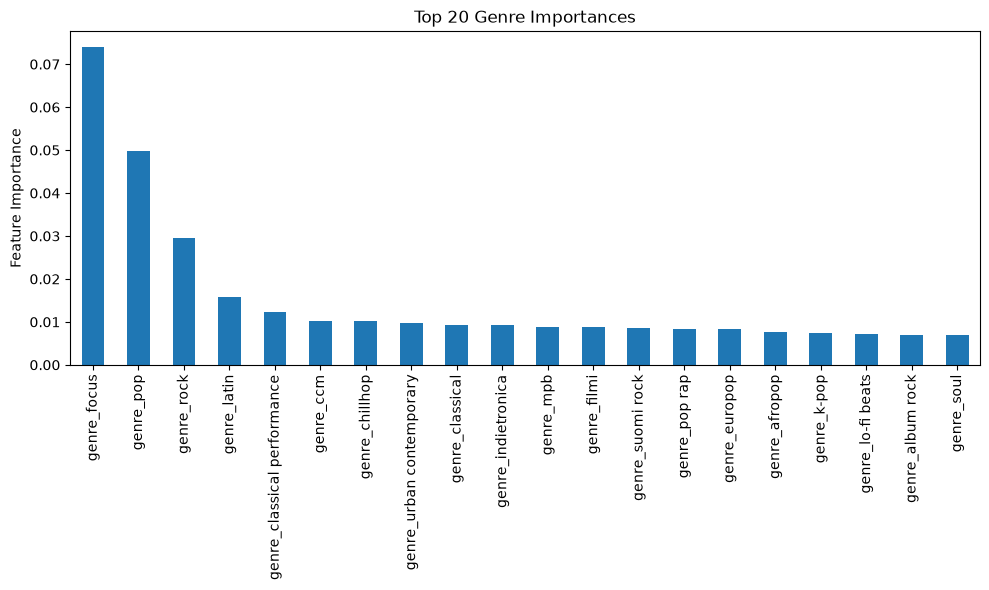

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature importances
importance = pd.Series(
    xgb.feature_importances_,
    index=X_train.columns
)

# Keep only genre columns
genre_importance = importance[importance.index.str.contains("genre", case=False)]

# Plot the 20 most important genres
top_genres = genre_importance.sort_values(ascending=False).head(20)

plt.figure(figsize=(10,6))
top_genres.plot(kind="bar")
plt.ylabel("Feature Importance")
plt.title("Top 20 Genre Importances")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()